# In Depth: Linear Regression

linear regression models are a great start for regression tasks.

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
import numpy as np

## Simple Linear Regression

The most familiar linear regression is a straight-line fit:
$$y = ax + b$$

where $a$ is commonly known as the slope, and $b$ as the $y$-intercept.

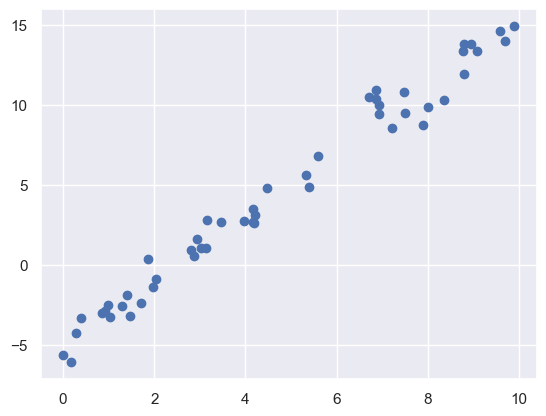

In [4]:
rng = np.random.RandomState(1)
x = 10 * rng.rand(50)
y = 2 * x - 5 + rng.randn(50)
plt.scatter(x,y);

We can use the `LinearRegression` class from the scikit learn library to fit a straight line on the data

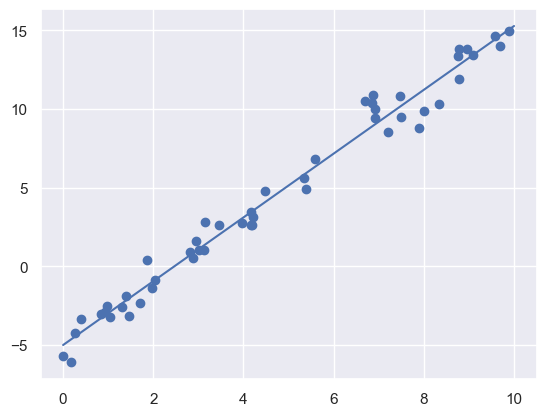

In [7]:
from sklearn.linear_model import LinearRegression

model = LinearRegression(fit_intercept=True)
X = x[:, np.newaxis] #Features matrix

model.fit(X,y)

xfit = np.linspace(0,10,1000)
yfit = model.predict(xfit[:, np.newaxis])

plt.scatter(x,y)
plt.plot(xfit, yfit);

Coefficients $a$ and $b$ are saved in attributes `.coef_` and `.intercept_`, respectively.

In [8]:
print('Slope (a):    ', model.coef_[0])
print('Intercept (b):', model.intercept_)

Slope (a):     2.027208810360695
Intercept (b): -4.998577085553202


## Multiple Linear Regression

Another regression technique is multiple linear regression:

$$y = a_0 + a_1 x_1 + a_2 x_2 + \cdots + a_n x_n$$

Where $n$ is the number of features in the features matrix. This is equivalent to fitting a plane if $n=3$ or a hyperplane if $n\geq 4$

We use Scikit-Learns's `LinearRegression` for multiple linear regression as well.

In [11]:
X = 10 * rng.rand(100,3) #Features matrix with 3 features
y = 0.5 * np.dot(X, [1.5,-2.,1.])

model.fit(X,y)
print(model.intercept_)
print(model.coef_)

-3.1086244689504383e-15
[ 0.75 -1.    0.5 ]


## Basis Function Regression

We can still use a linear regression model to model nonlinear relationships by transforming the data according to *basis functions*.

Suppose the relationship between the target `y` and a single feature `x` is nonlinear. We take our multiple linear regression model $$y = a_0 + a_1x_1 + \cdots +a_nx_n$$ and build $x_1, x_2, \cdots, x_n$ from $x$ with transformations: That is, we let $x_i = f_i(x)$ where each $f_i$ is some function.

### Example: Polynomial basis functions
In this case, $f_i(x)=x^i$. So, we model the nonlinear relationship of `x` and `y` with
\begin{align*}
    y &= a_0 + a_1 f_1(x) + a_2 f_2(x) + \cdots + a_n f_n(x) \\
    y &= a_0 + a_1 x + a_2 x^2 + \cdots + a_n x^n
\end{align*}

Take note that this is still multiple linear regression! Instead of nonlinear regression, we model the one-dimensional nonlinear relationship by projecting it onto higher dimensions using multiple linear regression.

Scikit-learn's `PolynomialFeatures` class can be used to construct our basis functions $x_i=f_i(x)$ for use with multiple linear regression.

In [12]:
from sklearn.preprocessing import PolynomialFeatures
x = np.array([2, 3, 4]) #one dimensional input x

# Construct x, x^2, x^3
poly = PolynomialFeatures(degree=3, include_bias=False)
poly.fit_transform(x[:, None])

array([[ 2.,  4.,  8.],
       [ 3.,  9., 27.],
       [ 4., 16., 64.]])

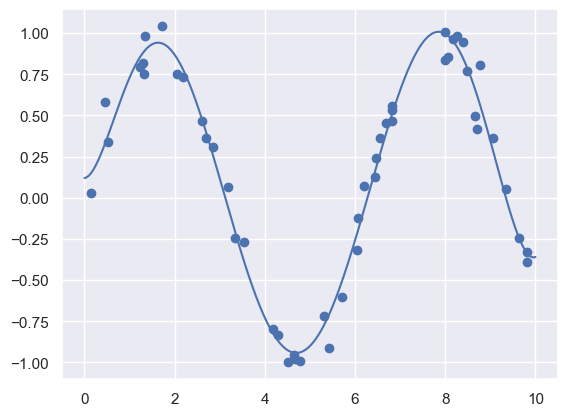

In [73]:
# Demo: Fitting a nonlinear curve with multiple linear regression
# Use a pipeline -- our model will do transformation + curve-fitting
from sklearn.pipeline import Pipeline

# Create model instance - we'll fit a polynomial of degree 7
model = Pipeline([
    ('transform', PolynomialFeatures(degree=7, include_bias=False)),
    ('fit', LinearRegression(fit_intercept=True))
])

# Arrange data
x = 10 * rng.rand(50)
y = np.sin(x) + 0.1 * rng.randn(50)

# Fit model
yfit = model.fit(x[:,np.newaxis],y).predict(xfit[:,np.newaxis])

# Plot
plt.scatter(x,y)
plt.plot(xfit,yfit);

### Example: Gaussian Basis Functions
In this case, our basis functions are Gaussian functions:
$$f_k(x) = \exp\left(-\frac{(x-k)^2}{2\sigma^2}\right)$$

$k$ is the position of the center of the peak, $\sigma$ controls the width of the bell.

Unfortunately, Scikit-Learn does not have a transformer that generates Gaussian Features. But this is a good time to explore Scikit-Learn's `BaseEstimator` and `TransformerMixin` classes for creating our own class of models from scratch!

Using `BaseEstimator` and `TransformMixin` as the parent classes will make our model compatible with Scikit-Learn.

In [75]:
from sklearn.base import BaseEstimator, TransformerMixin

class GaussianFeatures(BaseEstimator, TransformerMixin):
    """Uniformly spaced Gaussian features for one-dimensional input"""

    def __init__(self, N, width_factor=2.0):
        """
        N is the number of Gaussian function
        width_factor is the width of each Gaussian function; default value = 2.0
        """
        self.N = N
        self.width_factor = width_factor

    @staticmethod
    def _gauss_basis(X, centers, width):
        """
        Return the Gaussian features matrix.
        
        X is assumed to be an array with shape (n_samples, 1)
        centers is assumed to be the array containing the centers of the Gaussian functions
        width is assumed to be the width of the Gaussian functions (same width for all)
        """
        # This is a utility function used within the transform function
        arg = (X - centers) / width
        return np.exp(-0.5 * arg**2)

    def fit(self, X, y=None):
        """
        Returns the self fitted to the features matrix X

        X is assumed to contain only one feature, i.e., X.shape == (n_samples, 1)
        """
        # Generate centers of the Gaussians
        self.centers_ = np.linspace(X.min(), X.max(), self.N)

        # Generate width -- one width for all
        self.width_ = self.width_factor * (self.centers_[1] - self.centers_[0])

        return self

    def transform(self, X):
        """
        Returns the Gaussian features matrix based on X.

        X is assumed to be a features matrix with shape (n_samples, 1)
        """
        return self._gauss_basis(X, self.centers_, self.width_)

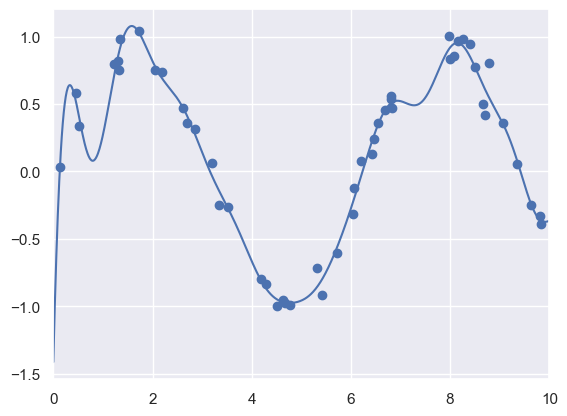

In [77]:
model = Pipeline([
    ('features', GaussianFeatures(20)),
    ('fit', LinearRegression())
])

yfit = model.fit(x[:,np.newaxis], y).predict(xfit[:,np.newaxis])

plt.scatter(x,y)
plt.plot(xfit, yfit)
plt.xlim(0, 10);

## Regularization